## Requirements

To ensure **readability** and **reproducibility**, it is necessary to download the datasets from the following link:
https://drive.google.com/drive/folders/12jA8vB3oqS7BMCfgg9-ZkKR33ShG49i4?usp=sharing .

The link contains the cleaned Google Play datasets and an external dataset "Flash Eurobarometer 388", which can also be found through the official link provided below.

---

## Data-Driven Market & Needs Analysis - Sustainable Lifestyle App :<span style="color:green; font-weight:600;"> GreenGap</span> of <span style="color:steelblue; font-weight:600;">Simone Lancia</span>

## Goal
This notebook uses two data sources:
- **Google Play Store Apps**: to understand market dynamics (competition, interest, freemium/free, ratings/installs).
- **Flash Eurobarometer 388 (EU28)**: to validate the real need (waste, recycling, barriers, information gaps) and estimate target reachability.

## Expected outputs
1) Identify a promising category (Lifestyle) + business model (free/freemium)  
2) Show “real user” evidence that justifies interactive features (not a wiki)  
3) Conclude with a product and monetization strategy consistent with the data

In [1]:
# Libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned datasets
apps = pd.read_csv("googleplaystore_clean.csv")
reviews = pd.read_csv("googleplaystore_user_reviews_clean.csv")

# Check the dimensions
apps.shape, reviews.shape

((9659, 13), (37427, 5))

In [3]:
def plot_histogram(series, bins=20, title="", xlabel="", ylabel="", log_x=False):
    plt.figure(figsize=(8,5))
    plt.hist(series.dropna(), bins=bins, edgecolor="black")
    if log_x:
        plt.xscale("log")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_scatter(x, y, title="", xlabel="", ylabel="", log_x=False, log_y=False):
    plt.figure(figsize=(10,6))
    plt.scatter(x, y)

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def add_bar_labels(bars, as_percent=False, fontsize=10, pad=0.01):
    """
    Adds labels above the bars.
    - as_percent=True: formats as percentage (0–1 -> 0–100%)
    - pad: vertical spacing (in y-axis units)
    """
    ax = plt.gca()
    ymax = ax.get_ylim()[1]

    for b in bars:
        val = b.get_height()
        if val is None:
            continue

        txt = f"{val*100:.0f}%" if as_percent else f"{val:.0f}"
        ax.text(
            b.get_x() + b.get_width()/2,
            val + ymax * pad,
            txt,
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

def add_bar_labels_vertical(bars, as_percent=False, fontsize=10, pad=0.01, format_large=False):
    ax = plt.gca()
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1

    for b in bars:
        val = b.get_height()
        if val is None:
            continue

        if as_percent:
            txt = f"{val*100:.0f}%"
        elif format_large:
            if val >= 1_000_000:
                txt = f"{val/1_000_000:.1f}M"
            elif val >= 1_000:
                txt = f"{val/1_000:.1f}K"
            else:
                txt = f"{val:.0f}"
        else:
            txt = f"{val:.0f}"

        ax.text(
            b.get_x() + b.get_width()/2,
            val + ymax * pad,
            txt,
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

def add_bar_labels_horizontal(bars, as_percent=False, fontsize=10, pad=0.01):
    ax = plt.gca()
    xmax = ax.get_xlim()[1] if ax.get_xlim()[1] else 1

    for b in bars:
        val = b.get_width()
        if val is None:
            continue
        txt = f"{val*100:.0f}%" if as_percent else f"{val:.0f}"
        ax.text(
            val + xmax * pad,
            b.get_y() + b.get_height()/2,
            txt,
            ha="left",
            va="center",
            fontsize=fontsize
        )

In [4]:
apps.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Facebook,SOCIAL,4.1,78158306,Varies with device,1000000000,Free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,Instagram,SOCIAL,4.5,66577446,Varies with device,1000000000,Free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,Clash of Clans,GAME,4.6,44893888,98M,100000000,Free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


In [5]:
apps.info()


<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            9659 non-null   str    
 5   Installs        9659 non-null   int64  
 6   Type            9658 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Last Updated    9659 non-null   str    
 11  Current Ver     9651 non-null   str    
 12  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(9)
memory usage: 981.1 KB


In [6]:
apps.columns


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [7]:
apps.isna().sum()


App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

The dataset appears overall **well-structured**, with missing values mainly limited to the **Rating** variable. This aspect is consistent with the nature of the data, as many applications do not have a sufficient number of reviews to receive a rating.

In [8]:
apps.describe()


,Rating,Reviews,Installs,Price
count,8196.000000,9.659000e+03,9.659000e+03,9659.000000
mean,4.173267,2.168041e+05,7.798170e+06,1.097231
std,0.536253,1.831430e+06,5.376973e+07,16.851618
min,1.000000,0.000000e+00,0.000000e+00,0.000000
25%,4.000000,2.500000e+01,1.000000e+03,0.000000
50%,4.300000,9.690000e+02,1.000000e+05,0.000000
75%,4.500000,2.945350e+04,1.000000e+06,0.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000


In [9]:
apps["Rating"].describe()


count    8196.000000
mean        4.173267
std         0.536253
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [10]:
apps[["Reviews", "Installs"]].describe()


,Reviews,Installs
count,9.659000e+03,9.659000e+03
mean,2.168041e+05,7.798170e+06
std,1.831430e+06,5.376973e+07
min,0.000000e+00,0.000000e+00
25%,2.500000e+01,1.000000e+03
50%,9.690000e+02,1.000000e+05
75%,2.945350e+04,1.000000e+06
max,7.815831e+07,1.000000e+09


The analysis of the **Reviews** and **Installs** variables shows a strongly skewed distribution, with medians of **969** reviews and **100,000** installs respectively, compared to extremely high maximum values.

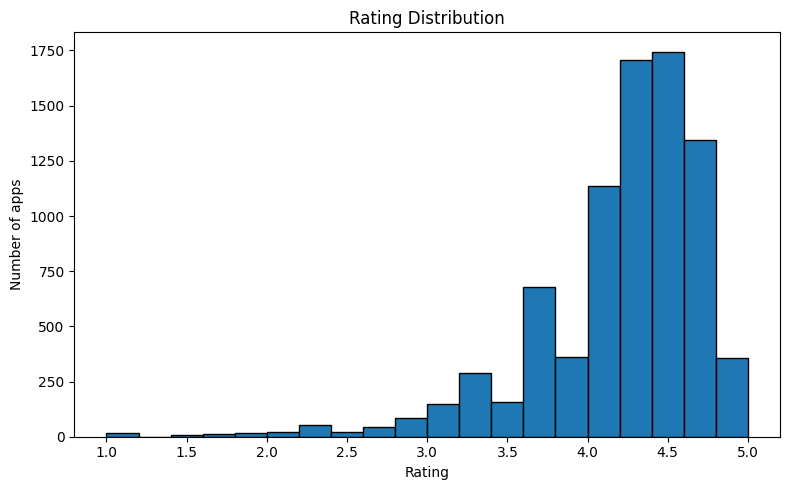

In [11]:
plot_histogram(
    apps["Rating"],
    bins=20,
    title="Rating Distribution",
    xlabel="Rating",
    ylabel="Number of apps"
)

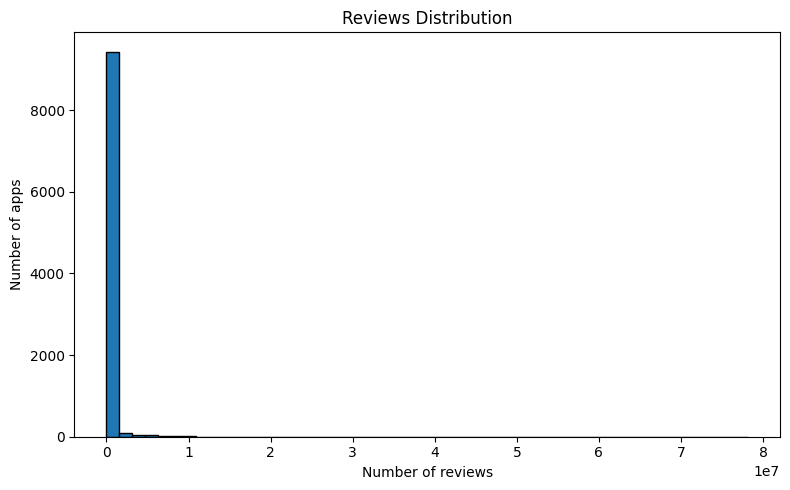

In [12]:
plot_histogram(
    series=apps["Reviews"],
    bins=50,
    title="Reviews Distribution",
    xlabel="Number of reviews",
    ylabel="Number of apps"
)

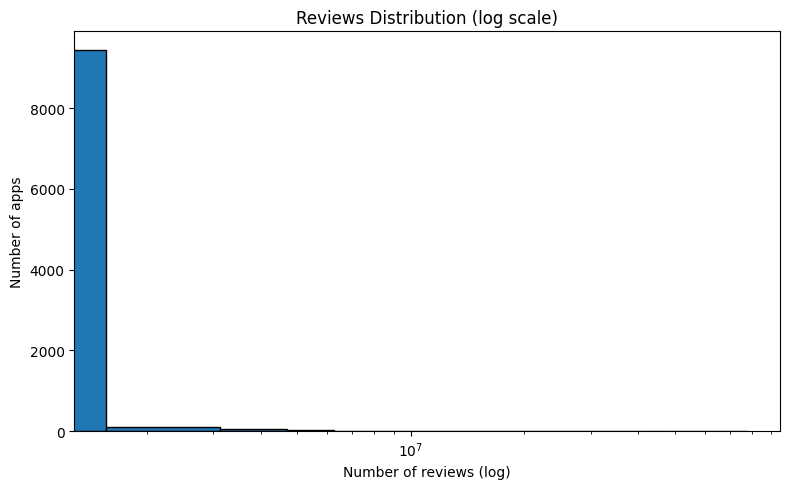

In [13]:
plot_histogram(
    series=apps["Reviews"],
    bins=50,
    title="Reviews Distribution (log scale)",
    xlabel="Number of reviews (log)",
    ylabel="Number of apps",
    log_x=True
)

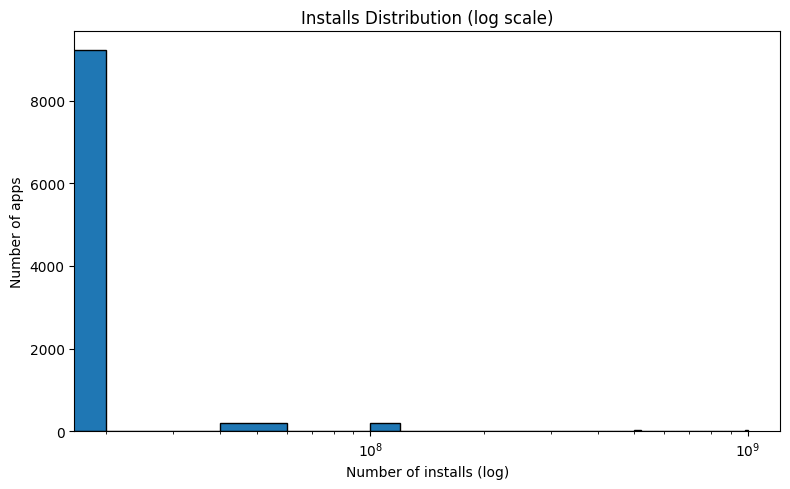

In [14]:
plot_histogram(
    series=apps["Installs"],
    bins=50,
    title="Installs Distribution (log scale)",
    xlabel="Number of installs (log)",
    ylabel="Number of apps",
    log_x=True
)

Even when adopting a logarithmic scale, the distributions of **Reviews** and **Installs** remain highly skewed, highlighting a clear concentration of applications with **low values** and a **long tail** of a few extreme cases.

In [15]:
apps["Category"].value_counts()


Category
FAMILY                 1875
GAME                    945
TOOLS                   829
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  170
VIDEO_PLAYERS           164
MAPS_AND_NAVIGATION     131
FOOD_AND_DRINK          112
EDUCATION               107
ENTERTAINMENT            87
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           73
EVENTS                   64
ART_AND_DESIGN           61
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [16]:
apps.groupby("Category")["Installs"].mean().sort_values(ascending=False)


Category
COMMUNICATION          3.504215e+07
VIDEO_PLAYERS          2.397502e+07
SOCIAL                 2.296179e+07
PHOTOGRAPHY            1.657704e+07
PRODUCTIVITY           1.548955e+07
GAME                   1.423061e+07
TRAVEL_AND_LOCAL       1.321866e+07
ENTERTAINMENT          1.137540e+07
TOOLS                  9.774152e+06
NEWS_AND_MAGAZINES     9.327629e+06
BOOKS_AND_REFERENCE    7.504367e+06
SHOPPING               6.932420e+06
WEATHER                4.570893e+06
PERSONALIZATION        4.075784e+06
HEALTH_AND_FITNESS     3.972300e+06
MAPS_AND_NAVIGATION    3.841846e+06
SPORTS                 3.373768e+06
FAMILY                 3.323489e+06
FOOD_AND_DRINK         1.891060e+06
ART_AND_DESIGN         1.856362e+06
EDUCATION              1.775252e+06
BUSINESS               1.659916e+06
LIFESTYLE              1.365375e+06
HOUSE_AND_HOME         1.331541e+06
FINANCE                1.319851e+06
DATING                 8.289712e+05
COMICS                 8.032348e+05
LIBRARIES_AND_DEMO 

In [17]:
apps.groupby("Category")["Installs"].median().sort_values(ascending=False)


Category
EDUCATION              1000000.0
SHOPPING               1000000.0
ENTERTAINMENT          1000000.0
GAME                   1000000.0
PHOTOGRAPHY            1000000.0
VIDEO_PLAYERS          1000000.0
WEATHER                1000000.0
HOUSE_AND_HOME          500000.0
FOOD_AND_DRINK          300000.0
ART_AND_DESIGN          100000.0
PARENTING               100000.0
MAPS_AND_NAVIGATION     100000.0
PRODUCTIVITY            100000.0
HEALTH_AND_FITNESS      100000.0
AUTO_AND_VEHICLES       100000.0
COMICS                  100000.0
COMMUNICATION           100000.0
TRAVEL_AND_LOCAL        100000.0
SOCIAL                  100000.0
SPORTS                  100000.0
NEWS_AND_MAGAZINES       50000.0
FAMILY                   50000.0
BEAUTY                   50000.0
TOOLS                    50000.0
BOOKS_AND_REFERENCE      10000.0
LIFESTYLE                10000.0
PERSONALIZATION          10000.0
DATING                   10000.0
FINANCE                  10000.0
LIBRARIES_AND_DEMO       10000.0
B

The analysis by **category** shows how some areas have a high concentration of applications, while others demonstrate a good level of user interest despite maintaining lower competition.

In [18]:
category_summary = apps.groupby("Category").agg(
    app_count=("App", "count"),
    median_installs=("Installs", "median")
).reset_index()

category_summary.head()


,Category,app_count,median_installs
0,ART_AND_DESIGN,61,100000.0
1,AUTO_AND_VEHICLES,85,100000.0
2,BEAUTY,53,50000.0
3,BOOKS_AND_REFERENCE,222,10000.0
4,BUSINESS,420,1000.0


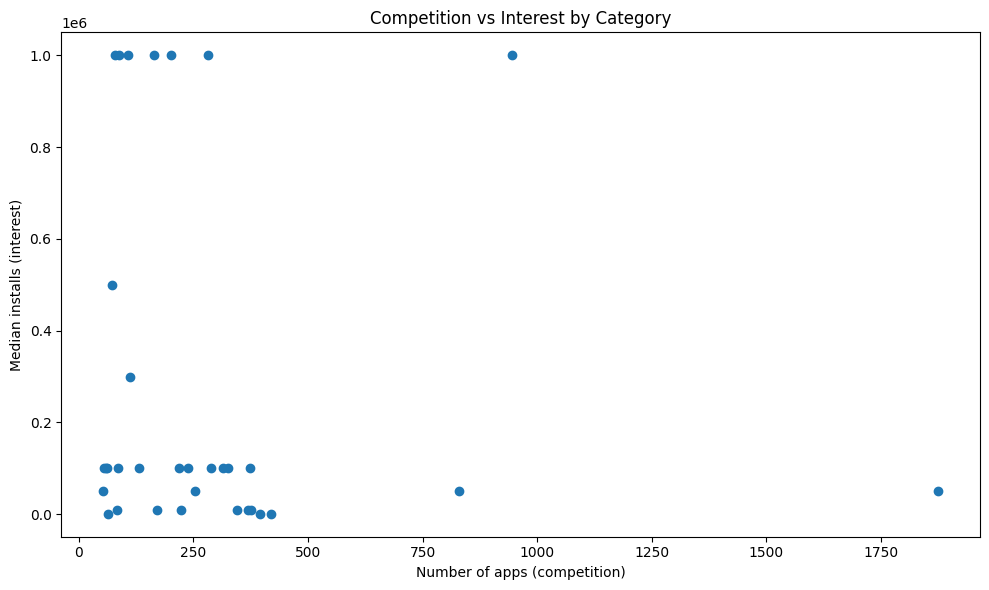

In [19]:
plot_scatter(
    x=category_summary["app_count"],
    y=category_summary["median_installs"],
    title="Competition vs Interest by Category",
    xlabel="Number of apps (competition)",
    ylabel="Median installs (interest)"
)

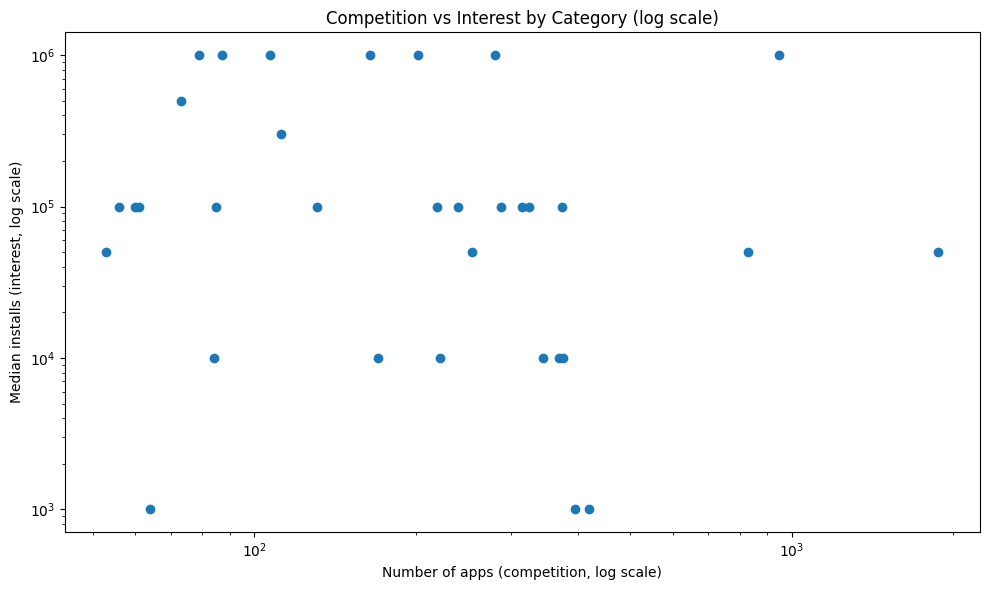

In [20]:
plot_scatter(
    x=category_summary["app_count"],
    y=category_summary["median_installs"],
    title="Competition vs Interest by Category (log scale)",
    xlabel="Number of apps (competition, log scale)",
    ylabel="Median installs (interest, log scale)",
    log_x=True,
    log_y=True
)

The **comparison** between the level of competition and user interest shows that some categories are positioned in a **favorable** spot, characterized by significant demand alongside relatively low competition. These categories represent potential areas of **opportunity** for the development of a new application.

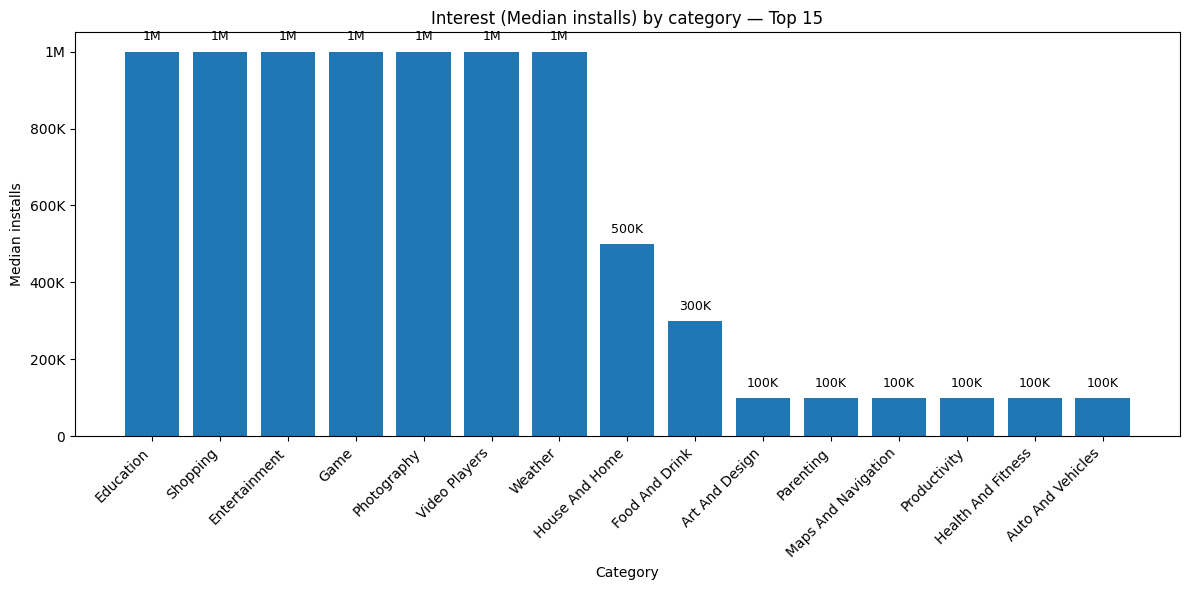

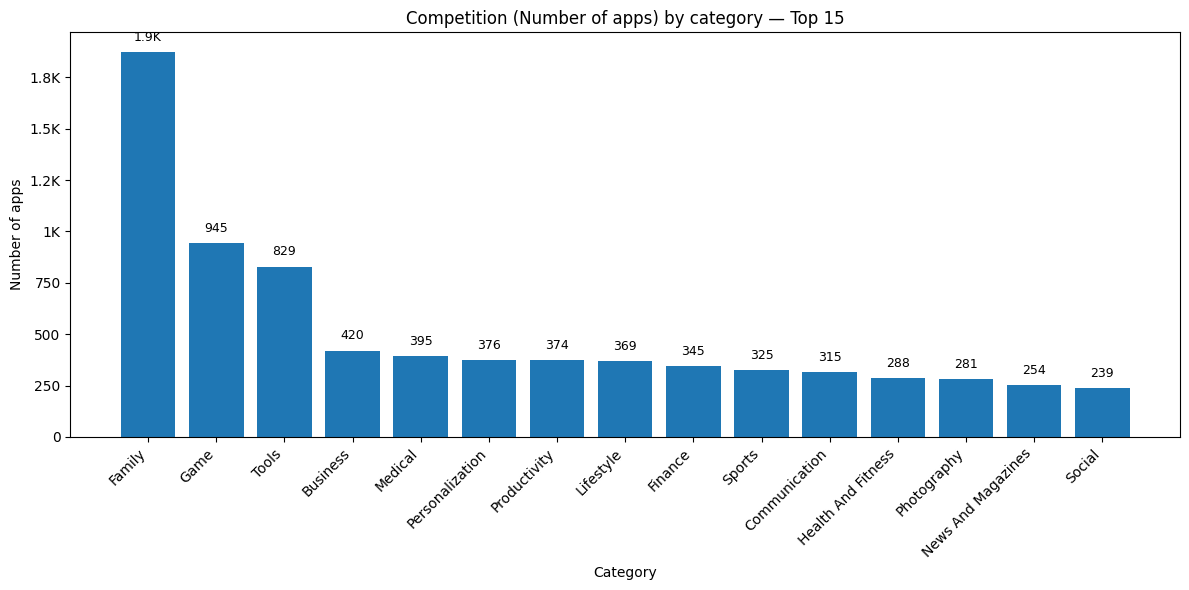

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- helper formatter ---
def short_num(x, pos=None):
    x = float(x)

    if x >= 1_000_000:
        val = x / 1_000_000
        return f"{val:.1f}M" if val % 1 != 0 else f"{int(val)}M"

    if x >= 1_000:
        val = x / 1_000
        return f"{val:.1f}K" if val % 1 != 0 else f"{int(val)}K"

    return f"{int(x)}"


# --- create summary if it does not already exist (it does no harm if it exists) ---
category_summary = (
    apps
    .groupby("Category", as_index=False)
    .agg(
        app_count=("App", "count") if "App" in apps.columns else ("Category", "size"),
        median_installs=("Installs", "median")
    )
)

# --- sort by interest ---
sorted_summary = category_summary.sort_values("median_installs", ascending=False).copy()

# --- clean category labels ---
sorted_summary["Category"] = (
    sorted_summary["Category"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)

# --- (optional) limit to Top N for readability ---
TOP_N = 15
sorted_top = sorted_summary.head(TOP_N).copy()

# ========== CHART 1: INTEREST ==========
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_top["Category"], sorted_top["median_installs"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Interest (Median installs) by category — Top {TOP_N}")
plt.xlabel("Category")
plt.ylabel("Median installs")

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(short_num))

# labels above the bars (short)
ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1
for b in bars:
    val = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        val + ymax * 0.02,
        short_num(val),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ========== CHART 2: COMPETITION ==========
# Sort by competition (so this chart also makes sense)
sorted_comp = category_summary.sort_values("app_count", ascending=False).copy()
sorted_comp["Category"] = (
    sorted_comp["Category"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.title()
)
sorted_comp_top = sorted_comp.head(TOP_N).copy()

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_comp_top["Category"], sorted_comp_top["app_count"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Competition (Number of apps) by category — Top {TOP_N}")
plt.xlabel("Category")
plt.ylabel("Number of apps")

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(short_num))

ymax = ax.get_ylim()[1] if ax.get_ylim()[1] else 1
for b in bars:
    val = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        val + ymax * 0.02,
        short_num(val),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

User interest is strongest in **Education**, **Shopping**, and **Entertainment**, but the charts confirm that high volumes do not guarantee an easy path: saturation in **Family**, **Game**, and **Tools** is brutal. The winning move is to target categories with a strong median of installs while avoiding segments where the crowd is too dense to stand out.

### Correlation between Rating and popularity (Installs)
To understand whether the most installed apps also tend to have higher ratings, I compute the correlation between **Rating** and **Installs**.  
I will use both **Pearson** (linear relationship) and **Spearman** (monotonic relationship, more robust when data is non-linear or contains outliers).

In [22]:
import numpy as np

# keep only valid rows
corr_df = apps.dropna(subset=["Rating", "Installs"]).copy()

# Installs is highly skewed: use log to make the plot more readable
corr_df["log_installs"] = np.log1p(corr_df["Installs"])

pearson = corr_df[["Rating", "log_installs"]].corr(method="pearson").iloc[0, 1]
spearman = corr_df[["Rating", "log_installs"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson (Rating vs log(Installs+1)):  {pearson:.3f}")
print(f"Spearman (Rating vs log(Installs+1)): {spearman:.3f}")

Pearson (Rating vs log(Installs+1)):  0.085
Spearman (Rating vs log(Installs+1)): 0.027


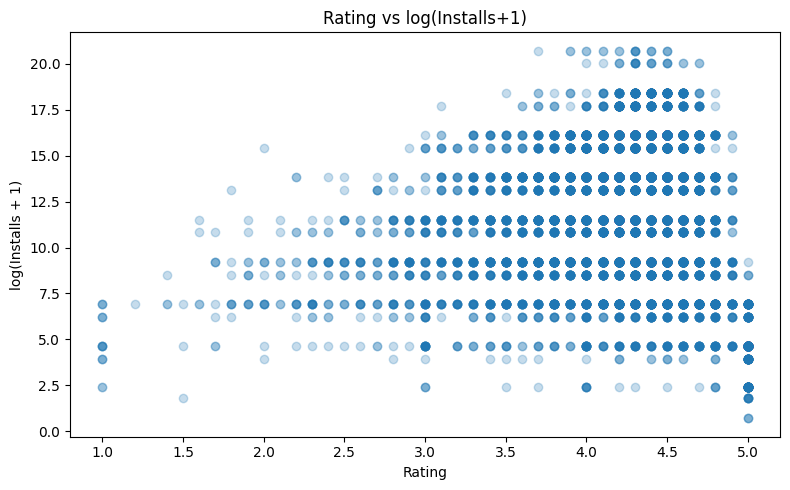

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(corr_df["Rating"], corr_df["log_installs"], alpha=0.25)

plt.title("Rating vs log(Installs+1)")
plt.xlabel("Rating")
plt.ylabel("log(Installs + 1)")
plt.tight_layout()
plt.show()

### Interpretation:
The analysis of the relationship between **Rating** and **Installs** **(on a logarithmic scale)** shows a positive trend: in general, as the rating increases, installs also tend to increase. However, the dispersion of the points indicates that the relationship is not perfectly linear.  
The **Pearson** coefficient measures linear correlation and can be influenced by the uneven distribution of installs. The **Spearman** coefficient, based on ranks, is more suitable in this case because it better captures monotonic relationships even when they are not strictly linear.

In short: there is a relationship between perceived quality (rating) and success (installs), but rating alone does not fully explain download volume. This reinforces the idea that factors such as category, visibility, and business model play a key role.

---

## From category selection to real need: why “Lifestyle” and why Eurobarometer 388

Based on the analysis conducted, the **Lifestyle** category emerges as a potential area of opportunity for developing a new sustainability-focused application. This category offers an interesting balance between **level of competition** and **user interest**, making it suitable for a project designed to combine **reach**, **environmental impact**, and **economic sustainability**.

The dataset analysis also shows that applications with the highest number of installs are predominantly **free**. This suggests that a **free** or **freemium** model is the most effective choice to drive broad initial adoption: in a highly competitive environment like the Google Play Store, lowering entry barriers is crucial to attract new users and build a solid base from the early stages of launch.

In line with the Lifestyle category and the chosen business model, the app should focus on **waste reduction** and **improving daily habits**: not a “wiki to browse”, but an **interactive** tool that supports people in their real everyday decisions.

The app could also include very concrete elements such as:

• **Consumption habit tracking**, helping users become more aware of their daily choices;

• **Waste reduction support tools**, for example through practical suggestions for product reuse or better shopping planning;

• **Visual feedback on the impact of actions**, showing in a simple way how certain choices contribute to a more responsible use of resources;

• **Personalized reminders** (e.g., collection days or checking what is “about to expire” at home);

• **Label / recycling symbol scanner**, to quickly understand where to dispose of packaging and how to sort it correctly;

• **Checklists and weekly goals** (small steps, not impossible missions) with visible progress;

• **Map of useful locations** (recycling centers, e-waste collection points, drop-off locations) and, where available, external incentive systems (such as supermarket reward points) linked to recycling;

• **Internal points system and community**, to encourage app usage and engagement with sustainability.

At this point, however, to design a credible app one key aspect must be validated: **is the need actually perceived by people?** And where is there the greatest room for improvement?  
To answer this in a data-driven way, I integrated the analysis with the **Flash Eurobarometer 388** dataset (link: https://webgate.ec.europa.eu/eurobarometer/api/public/odp/download?key=A5643BCE9DB6B07020F75A32D887B2FB), a European-level survey that allows observation of **behaviors**, **perceptions**, **barriers**, and **information gaps** related to recycling, waste, and consumption choices.

In practice: the European dataset is perfect to demonstrate not only the usefulness of the app, but also the presence of a **potential market** (people who are interested, but often do not clearly know *how* to act or struggle to do so consistently).

In [24]:
q42 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q4.2", header=None)

# parse table
header_row = 8
q42_table = q42.copy()
q42_table.columns = q42_table.iloc[header_row]
q42_table = q42_table.iloc[header_row+1:].reset_index(drop=True)

# extract EN rows with percentages
label_series = q42_table.iloc[:, 1].astype(str)
value_series = pd.to_numeric(q42_table.iloc[:, 2], errors="coerce")

labels_en = [
    "Totally agree",
    "Tend to agree",
    "Tend to disagree",
    "Totally disagree"
]

mask = label_series.isin(labels_en)

q42_eu = pd.DataFrame({
    "response": label_series[mask].values,
    "EU28": value_series[mask].values
}).set_index("response")

q42_eu

,EU28
response,
Totally agree,0.15
Tend to agree,0.28
Tend to disagree,0.34
Totally disagree,0.22


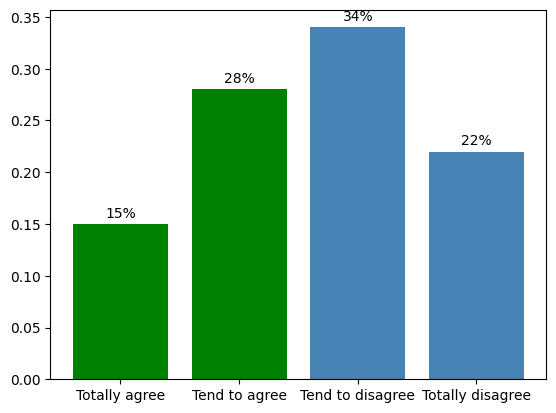

In [25]:
order = ["Totally agree", "Tend to agree", "Tend to disagree", "Totally disagree"]
q42_plot = q42_eu.loc[order].copy()

# Colors
colors = ["green", "green", "steelblue", "steelblue"]

# Compute totals
agree_total = q42_plot.loc["Totally agree", "EU28"] + q42_plot.loc["Tend to agree", "EU28"]
disagree_total = q42_plot.loc["Tend to disagree", "EU28"] + q42_plot.loc["Totally disagree", "EU28"]

# Chart
bars = plt.bar(q42_plot.index, q42_plot["EU28"], color=colors)
add_bar_labels(bars, as_percent=True)

The **chart** highlights that a significant share of the European population recognizes that their household produces **too much waste**. The fact that **43%** of respondents say they agree or totally agree indicates that the problem of household waste management is perceived as **real** and connected to everyday habits. This awareness represents a **potential interest** in practical tools that can help people improve waste management within their homes.

In [26]:
q6 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q6", header=None)

# Identify the header row
header_row = q6[q6.apply(lambda row: row.astype(str).str.contains("EU28", case=False).any(), axis=1)].index[0]

# Build clean table
q6_table = q6.copy()
q6_table.columns = q6_table.iloc[header_row]
q6_table = q6_table.iloc[header_row+1:].reset_index(drop=True)

q6_table.head(17)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,26595,1000,1000,1000,1008,1000,1000,1000,...,1001,1001,1002,1025,1023,1003,1005,1000,1007,1005
1,NaN,Le papier/ le carton / les briques de boissons,23846,972,637,922,797,978,847,950,...,987,861,909,514,900,925,927,940,942,762
2,NaN,Paper / Cardboard / Beverage cartons,0.9,0.97,0.64,0.92,0.79,0.98,0.85,0.95,...,0.99,0.86,0.91,0.5,0.88,0.92,0.92,0.94,0.94,0.76
3,NaN,Les bouteilles en plastique et autres matériau...,23901,966,662,960,762,959,879,941,...,940,911,899,611,930,932,819,946,939,897
4,NaN,Plastic bottles or other plastic materials,0.9,0.97,0.66,0.96,0.76,0.96,0.88,0.94,...,0.94,0.91,0.9,0.6,0.91,0.93,0.81,0.95,0.93,0.89
5,NaN,Les boîtes et canettes en métal,20817,943,503,556,743,854,740,883,...,902,825,826,357,851,607,861,903,898,587
6,NaN,Metal cans,0.78,0.94,0.5,0.56,0.74,0.85,0.74,0.88,...,0.9,0.82,0.82,0.35,0.83,0.61,0.86,0.9,0.89,0.58
7,NaN,Le verre,23330,971,582,920,918,976,750,914,...,960,871,911,400,896,884,890,971,872,644
8,NaN,Glass,0.88,0.97,0.58,0.92,0.91,0.98,0.75,0.91,...,0.96,0.87,0.91,0.39,0.88,0.88,0.89,0.97,0.87,0.64
9,NaN,Les déchets de cuisine,19577,830,471,657,525,861,695,795,...,836,704,807,360,893,659,774,757,786,511


In [27]:
waste_type = q6_table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
eu_values  = pd.to_numeric(q6_table.iloc[:, 2], errors="coerce")

# Create the base table and remove empty rows
q6_eu = pd.DataFrame({"Waste type": waste_type, "EU28": eu_values}).dropna()

# Keep only clean “textual” rows (in English)
q6_eu = q6_eu[q6_eu["Waste type"].str.match(r"^[A-Za-z0-9 /(),.\-']+$", na=False)]

# Filter only relevant entries
keywords = ["paper", "plastic", "glass", "metal", "kitchen", "garden", "hazardous", "electrical", "electronic"]
q6_eu = q6_eu[q6_eu["Waste type"].str.lower().apply(lambda s: any(k in s for k in keywords))]

# Remove duplicates keeping the maximum value
q6_eu = q6_eu.groupby("Waste type", as_index=False)["EU28"].max()

# Sort by percentage (from least recycled to most recycled)
q6_eu = q6_eu.sort_values("EU28", ascending=True).reset_index(drop=True)

q6_eu

,Waste type,EU28
0,Garden waste,0.57
1,Kitchen waste,0.74
2,Electrical and electronic waste,0.76
3,Metal cans,0.78
4,"Household hazardous waste (paint, chemicals, b...",0.79
5,Glass,0.88
6,Paper / Cardboard / Beverage cartons,0.90
7,Plastic bottles or other plastic materials,0.90


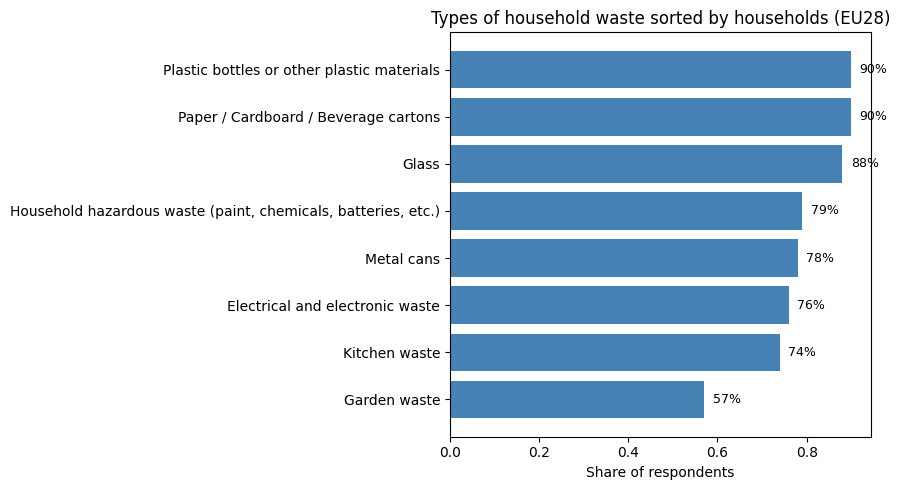

In [28]:
# Chart
plt.figure(figsize=(9, 5))
bars = plt.barh(q6_eu["Waste type"], q6_eu["EU28"], color="steelblue")
plt.xlabel("Share of respondents")
plt.title("Types of household waste sorted by households (EU28)")

add_bar_labels_horizontal(bars, as_percent=True, fontsize=9, pad=0.02)

plt.tight_layout()
plt.show()

People do recycle, but **not** in a systematic or complete way.  
While common materials such as paper, plastic, and glass are handled correctly by the majority of users, other categories, such as organic, electronic, and hazardous waste, **lag behind**.  
This **imbalance** suggests that household recycling becomes more fragile when it requires specific knowledge or less immediate actions. This indicates a solid **margin for improvement!**

In [29]:
q5a = pd.read_excel("FL388 Volume A.xls", sheet_name="Q5a", header=None)

# Identify the header row
header_row = q5a[q5a.apply(
    lambda row: row.astype(str).str.contains("EU28", case=False).any(),
    axis=1
)].index[0]

# Build clean table
q5a_table = q5a.copy()
q5a_table.columns = q5a_table.iloc[header_row]
q5a_table = q5a_table.iloc[header_row + 1:].reset_index(drop=True)

q5a_table.head(17)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,24660,949,934,914,803,942,879,967,...,932,914,938,955,954,912,924,911,964,911
1,NaN,Vous évitez le gaspillage de nourriture ou d’a...,20565,850,791,817,605,793,626,758,...,818,739,888,692,636,732,777,592,823,566
2,NaN,You avoid food waste and other types of waste ...,0.83,0.9,0.85,0.89,0.75,0.84,0.71,0.78,...,0.88,0.81,0.95,0.72,0.67,0.8,0.84,0.65,0.85,0.62
3,NaN,Vous évitez d’acheter des produits « suremball...,15294,600,558,436,369,676,391,640,...,665,640,708,458,514,574,612,450,641,379
4,NaN,You avoid buying ‘over packaged’ goods,0.62,0.63,0.6,0.48,0.46,0.72,0.45,0.66,...,0.71,0.7,0.75,0.48,0.54,0.63,0.66,0.49,0.66,0.42
5,NaN,Vous avez pris les mesures nécessaires pour ne...,13481,441,471,439,375,620,363,466,...,438,424,604,290,320,318,452,501,685,251
6,NaN,You have made an effort to stop receiving unwa...,0.55,0.47,0.5,0.48,0.47,0.66,0.41,0.48,...,0.47,0.46,0.64,0.3,0.34,0.35,0.49,0.55,0.71,0.28
7,NaN,Vous pratiquez le compostage à domicile,10789,504,241,554,366,519,455,502,...,618,417,381,245,535,488,525,485,418,368
8,NaN,You undertake home composting,0.44,0.53,0.26,0.61,0.46,0.55,0.52,0.52,...,0.66,0.46,0.41,0.26,0.56,0.54,0.57,0.53,0.43,0.4
9,NaN,Vous utilisez des piles rechargeables,14719,655,413,638,446,655,358,581,...,580,538,574,387,450,569,444,591,618,346


In [30]:
action = q5a_table.iloc[:, 1].astype(str)
eu_values = pd.to_numeric(q5a_table.iloc[:, 2], errors="coerce")

q5a_raw = pd.DataFrame({
    "Action": action,
    "EU28": eu_values
}).dropna()

# Clean strings
q5a_raw["Action"] = (
    q5a_raw["Action"]
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

# Keep ONLY percentage values
q5a_raw = q5a_raw[(q5a_raw["EU28"] > 0) & (q5a_raw["EU28"] <= 1)]

# Keep ONLY English rows
q5a_raw = q5a_raw[q5a_raw["Action"].str.startswith("You")]

# Remove irrelevant entries
exclude_terms = ["DK/NA", "NSP", "TOTAL", "DO NOT READ OUT"]
for term in exclude_terms:
    q5a_raw = q5a_raw[~q5a_raw["Action"].str.contains(term, case=False, na=False)]

# If duplicates, keep the max value
q5a_eu = q5a_raw.groupby("Action", as_index=False)["EU28"].max()

# Sort from LEAST common behavior to MOST common
q5a_rank = q5a_eu.sort_values("EU28", ascending=True).reset_index(drop=True)

q5a_rank

,Action,EU28
0,You undertake home composting,0.44
1,You have made an effort to stop receiving unwa...,0.55
2,You drink tap water to avoid packaging waste,0.59
3,You use rechargeable batteries,0.60
4,You avoid buying ‘over packaged’ goods,0.62
5,You donate/sell items for re-use,0.67
6,You make an effort to get broken appliances re...,0.77
7,You avoid food waste and other types of waste ...,0.83


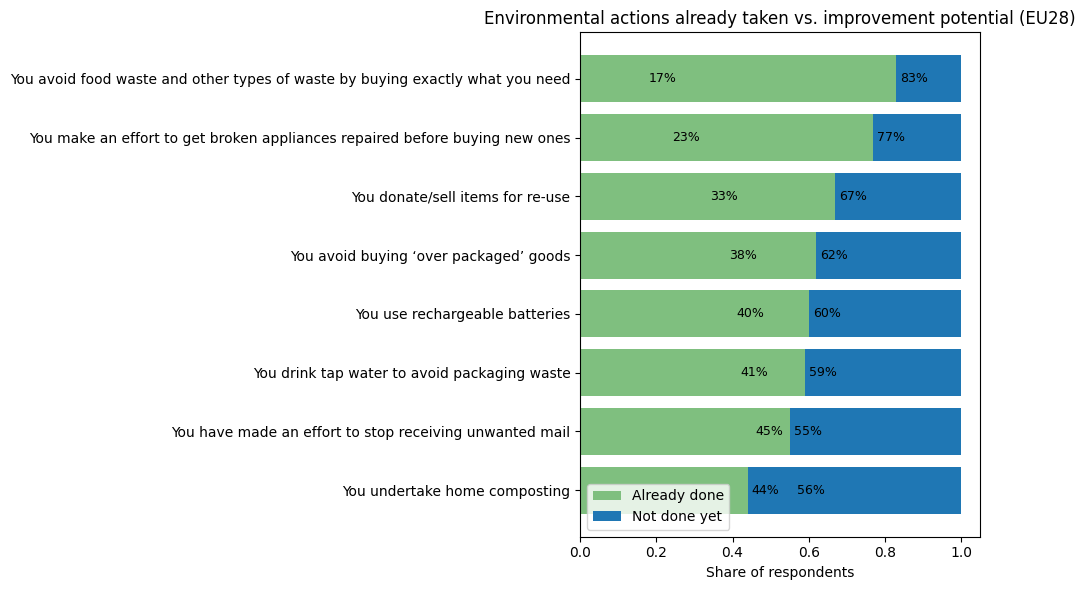

In [31]:
q5a_plot = q5a_rank.copy()
q5a_plot["Not done"] = 1 - q5a_plot["EU28"]

# Chart
plt.figure(figsize=(10, 6))

bars_done = plt.barh(
    q5a_plot["Action"],
    q5a_plot["EU28"],
    color="#7FBF7F",
    label="Already done"
)

bars_not = plt.barh(
    q5a_plot["Action"],
    q5a_plot["Not done"],
    left=q5a_plot["EU28"],
    color="#1F77B4",
    label="Not done yet"
)

plt.xlabel("Share of respondents")
plt.title("Environmental actions already taken vs. improvement potential (EU28)")
plt.legend()

# percentage labels
add_bar_labels_horizontal(bars_done, as_percent=True, fontsize=9, pad=0.01)
add_bar_labels_horizontal(bars_not, as_percent=True, fontsize=9, pad=0.01)

plt.tight_layout()
plt.show()

**None** of the analyzed actions reaches **100%** adoption, leaving significant room for improvement.  
This suggests that an app designed to make these practices simpler and more accessible could have a **real impact** on users’ daily habits.

In [32]:
q5b = pd.read_excel("FL388 Volume A.xls", sheet_name="Q5b", header=None)

# Find the header row
header_row = q5b[q5b.apply(
    lambda row: row.astype(str).str.contains("EU28", case=False).any(),
    axis=1
)].index[0]

# Set columns using the header row and remove rows above
q5b_table = q5b.copy()
q5b_table.columns = q5b_table.iloc[header_row]
q5b_table = q5b_table.iloc[header_row + 1:].reset_index(drop=True)

In [33]:
# Labels and EU28 values
label_series = q5b_table.iloc[:, 1].astype(str)
value_series = pd.to_numeric(q5b_table.iloc[:, 2], errors="coerce")

# Select the row that starts with "You don't know..."
mask = label_series.str.startswith("You don’t know") | label_series.str.startswith("You don't know")

# Create the final small table
q5b_row = pd.DataFrame({
    "Statement": label_series[mask].values,
    "EU28": value_series[mask].values
})

q5b_row

,Statement,EU28
0,You don’t know how you can reduce waste,0.3


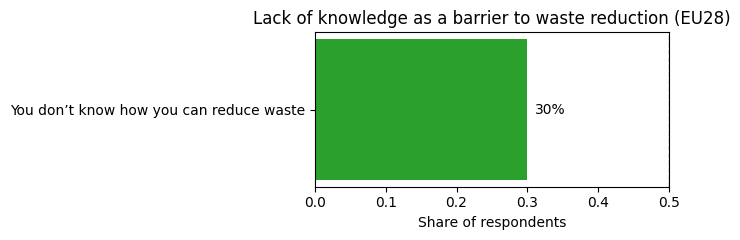

In [34]:
value = q5b_row["EU28"].iloc[0]

# Chart
plt.figure(figsize=(7, 2.5))
bars = plt.barh(
    ["You don’t know how you can reduce waste"],
    [value],
    color="#2ca02c"
)

plt.xlabel("Share of respondents")
plt.title("Lack of knowledge as a barrier to waste reduction (EU28)")

plt.xlim(0, 0.5)
plt.axvline(0.5, linestyle="--", linewidth=1)

# percentage labels
add_bar_labels_horizontal(bars, as_percent=True, fontsize=10, pad=0.02)

plt.tight_layout()
plt.show()

A fairly **significant** share of the European population states that they **do not know** how to reduce their waste.  
This shows that the **real barrier** is the lack of practical guidance: an app that provides simple, actionable advice would therefore have **huge value**.

In [35]:
q13 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q13", header=None)

# Identify the header row
header_row = q13[q13.apply(
    lambda row: row.astype(str).str.contains("EU28", case=False).any(),
    axis=1
)].index[0]

# Build clean table
q13_table = q13.copy()
q13_table.columns = q13_table.iloc[header_row]
q13_table = q13_table.iloc[header_row + 1:].reset_index(drop=True)

q13_table.head(11)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,4299,180,243,184,117,125,164,133,...,141,137,167,409,213,257,81,76,111,247
1,NaN,Des préoccupations de santé et de sécurité,1779,76,108,88,23,59,36,47,...,59,57,61,200,25,127,31,28,60,72
2,NaN,Health and safety concerns,0.41,0.43,0.44,0.48,0.19,0.47,0.22,0.36,...,0.42,0.42,0.36,0.49,0.12,0.49,0.39,0.37,0.54,0.29
3,NaN,Une moins bonne qualité du produit,1858,76,110,104,40,53,81,50,...,58,51,75,201,68,138,38,30,57,106
4,NaN,Inferior quality of the product,0.43,0.42,0.45,0.56,0.34,0.43,0.5,0.38,...,0.41,0.37,0.45,0.49,0.32,0.54,0.46,0.39,0.51,0.43
5,NaN,L’apparence moins attirante du produit,838,49,35,54,19,33,18,12,...,34,43,51,60,8,69,19,14,29,22
6,NaN,Less appealing look of the product,0.2,0.27,0.14,0.29,0.16,0.27,0.11,0.09,...,0.24,0.32,0.31,0.15,0.04,0.27,0.23,0.19,0.26,0.09
7,NaN,Peur de ce que les autres pourraient penser de...,155,12,10,12,2,3,6,1,...,5,11,14,19,4,24,2,0,4,4
8,NaN,Afraid of what others might think of you,0.04,0.07,0.04,0.07,0.02,0.02,0.03,0.01,...,0.03,0.08,0.08,0.05,0.02,0.09,0.02,0.01,0.04,0.02
9,NaN,Vous n’y avez jamais pensé,880,45,35,41,42,19,25,23,...,25,33,53,60,81,52,17,14,19,65


In [36]:
barrier = q13_table.iloc[:, 1].astype(str)
eu_values = pd.to_numeric(q13_table.iloc[:, 2], errors="coerce")

q13_raw = pd.DataFrame({
    "Barrier": barrier,
    "EU28": eu_values
}).dropna()

# Clean strings
q13_raw["Barrier"] = (
    q13_raw["Barrier"]
    .str.replace("\u00a0", " ", regex=False)
    .str.strip()
)

# Keep ONLY percentages
q13_raw = q13_raw[(q13_raw["EU28"] > 0) & (q13_raw["EU28"] <= 1)]

# Keep ONLY English rows
q13_raw = q13_raw[q13_raw["Barrier"].str.match(r"^[A-Z]", na=False)]

# Remove irrelevant entries
exclude_terms = ["DK/NA", "NSP", "TOTAL", "DO NOT READ OUT"]
for term in exclude_terms:
    q13_raw = q13_raw[~q13_raw["Barrier"].str.contains(term, case=False, na=False)]

# If duplicates, keep the correct percentage
q13_eu = q13_raw.groupby("Barrier", as_index=False)["EU28"].max()

# Top 5 barriers
q13_top5 = q13_eu.sort_values("EU28", ascending=False).head(5)

q13_top5

,Barrier,EU28
2,Inferior quality of the product,0.43
1,Health and safety concerns,0.41
3,Less appealing look of the product,0.20
4,Never thought of it,0.20
0,Afraid of what others might think of you,0.04


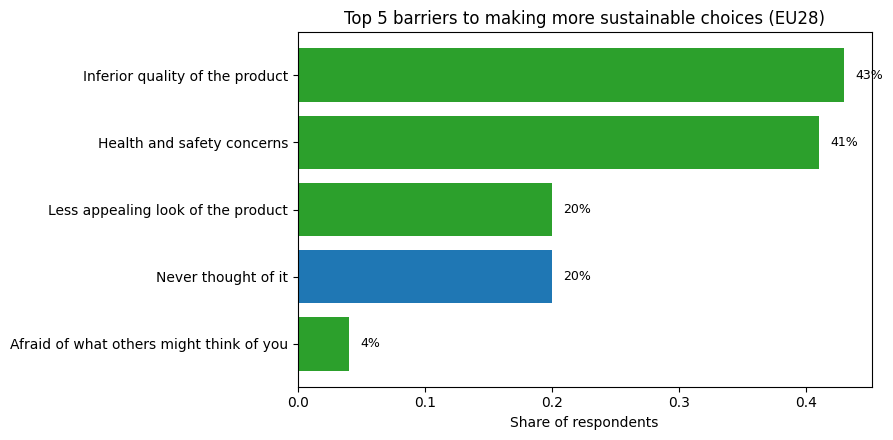

In [37]:
q13_plot = q13_top5.sort_values("EU28", ascending=True)

# Colors
colors = [
    "#1F77B4" if "Never thought of it" in barrier else "#2CA02C"
    for barrier in q13_plot["Barrier"]
]

# Chart
plt.figure(figsize=(9, 4.5))
bars = plt.barh(q13_plot["Barrier"], q13_plot["EU28"], color=colors)

plt.xlabel("Share of respondents")
plt.title("Top 5 barriers to making more sustainable choices (EU28)")

# percentage labels
add_bar_labels_horizontal(bars, as_percent=True, fontsize=9, pad=0.02)

plt.tight_layout()
plt.show()

Among the considered barriers, both **perceptual factors**, such as product quality and safety, and **cultural** and **informational** elements emerge as relevant.  
This suggests that a **digital guide** could help users overcome these obstacles, enabling more informed decisions in their daily choices.

In [38]:
q161 = pd.read_excel("FL388 Volume A.xls", sheet_name="Q16.1", header=None)

# Identify the header row
header_row = q161[q161.apply(
    lambda row: row.astype(str).str.contains("EU28", case=False).any(),
    axis=1
)].index[0]

# Build clean table
q161_table = q161.copy()
q161_table.columns = q161_table.iloc[header_row]
q161_table = q161_table.iloc[header_row + 1:].reset_index(drop=True)

q161_table.head(15)

8,NaN,NaN,UE28\nEU28,BE,BG,CZ,DK,DE,EE,IE,...,AT,PL,PT,RO,SI,SK,FI,SE,UK,HR
0,NaN,TOTAL,26595,1000,1000,1000,1008,1000,1000,1000,...,1001,1001,1002,1025,1023,1003,1005,1000,1007,1005
1,NaN,Tout à fait d’accord,20206,713,859,670,771,730,655,780,...,725,709,848,861,821,741,722,816,752,816
2,NaN,Totally agree,0.76,0.71,0.86,0.67,0.76,0.73,0.65,0.78,...,0.72,0.71,0.85,0.84,0.8,0.74,0.72,0.82,0.75,0.81
3,NaN,Plutôt d’accord,4844,222,95,260,167,198,220,177,...,208,238,122,115,139,213,230,125,183,155
4,NaN,Tend to agree,0.18,0.22,0.1,0.26,0.17,0.2,0.22,0.18,...,0.21,0.24,0.12,0.11,0.14,0.21,0.23,0.12,0.18,0.15
5,NaN,Plutôt pas d’accord,813,37,9,50,38,39,59,18,...,41,18,12,11,30,31,30,29,40,15
6,NaN,Tend to disagree,0.03,0.04,0.01,0.05,0.04,0.04,0.06,0.02,...,0.04,0.02,0.01,0.01,0.03,0.03,0.03,0.03,0.04,0.02
7,NaN,Pas du tout d’accord,449,23,14,9,22,18,19,18,...,21,23,12,29,25,11,13,17,14,12
8,NaN,Totally disagree,0.02,0.02,0.01,0.01,0.02,0.02,0.02,0.02,...,0.02,0.02,0.01,0.03,0.02,0.01,0.01,0.02,0.01,0.01
9,NaN,NSP/ SR,283,5,23,11,10,15,47,6,...,7,12,9,8,8,6,10,13,19,6


In [39]:
labels = q161_table.iloc[:, 1].astype(str)
values = pd.to_numeric(q161_table.iloc[:, 2], errors="coerce")

# Keep only the 4 standard responses
mask = (
    labels.str.contains("Totally agree", case=False, na=False) |
    labels.str.contains("Tend to agree", case=False, na=False) |
    labels.str.contains("Tend to disagree", case=False, na=False) |
    labels.str.contains("Totally disagree", case=False, na=False)
)

q161_eu = pd.DataFrame({
    "Response": labels[mask].values,
    "EU28": values[mask].values
}).set_index("Response")

q161_eu

,EU28
Response,
Totally agree,0.76
Tend to agree,0.18
Tend to disagree,0.03
Totally disagree,0.02


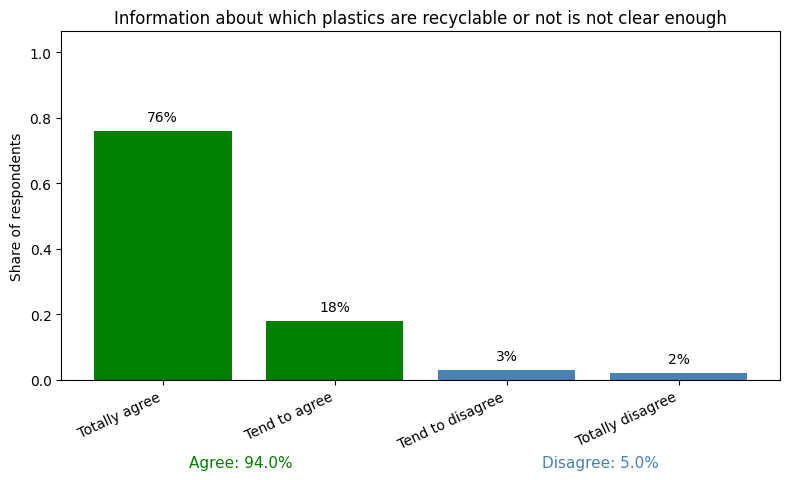

In [40]:
order = ["Totally agree", "Tend to agree", "Tend to disagree", "Totally disagree"]
q161_plot = q161_eu.loc[order].copy()

# Colors
colors = ["green", "green", "steelblue", "steelblue"]

agree_total = q161_plot.loc["Totally agree", "EU28"] + q161_plot.loc["Tend to agree", "EU28"]
disagree_total = q161_plot.loc["Tend to disagree", "EU28"] + q161_plot.loc["Totally disagree", "EU28"]

# Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(q161_plot.index, q161_plot["EU28"], color=colors)

plt.ylabel("Share of respondents")
plt.title("Information about which plastics are recyclable or not is not clear enough")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, q161_plot["EU28"].max() * 1.4)

# labels on bars
add_bar_labels_vertical(bars, as_percent=True, fontsize=10, pad=0.02)

# text below
plt.text(0.25, -0.25, f"Agree: {agree_total*100:.1f}%", color="green",
         fontsize=11, ha="center", transform=plt.gca().transAxes)
plt.text(0.75, -0.25, f"Disagree: {disagree_total*100:.1f}%", color="steelblue",
         fontsize=11, ha="center", transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

The **high** level of agreement indicates a widespread perception of the **lack of clarity** in information about the environmental impact of plastics.  
For this reason, an app could step in by providing practical solutions, such as guiding users in disposing of packaging by interpreting labels for them.  
Additionally, by integrating tools like maps of collection centers or local incentive programs, it would become much easier to turn user interest into **concrete actions**.

In [41]:
d11 = pd.read_excel("FL388 Volume A.xls", sheet_name="D1.1", header=None)

# Identify the header row
header_row = d11[d11.apply(lambda row: row.astype(str).str.contains("EU28", case=False).any(), axis=1)].index[0]

# Build clean table
d11_table = d11.copy()
d11_table.columns = d11_table.iloc[header_row]
d11_table = d11_table.iloc[header_row + 1:].reset_index(drop=True)

In [42]:
d13 = pd.read_excel("FL388 Volume A.xls", sheet_name="D13", header=None)

# Identify the header row
header_row = d13[d13.apply(lambda row: row.astype(str).str.contains("EU28", case=False).any(), axis=1)].index[0]

# Build clean table
d13_table = d13.copy()
d13_table.columns = d13_table.iloc[header_row]
d13_table = d13_table.iloc[header_row + 1:].reset_index(drop=True)

In [43]:
d18 = pd.read_excel("FL388 Volume A.xls", sheet_name="D18", header=None)

# Identify the header row
header_row = d18[d18.apply(lambda row: row.astype(str).str.contains("EU28", case=False).any(), axis=1)].index[0]

# Build clean table
d18_table = d18.copy()
d18_table.columns = d18_table.iloc[header_row]
d18_table = d18_table.iloc[header_row + 1:].reset_index(drop=True)

In [44]:
# D1.1 Age
labels_col = d11_table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
values_col = pd.to_numeric(d11_table.iloc[:, 2], errors="coerce")

d11_tmp = pd.DataFrame({"label": labels_col, "value": values_col})

# percentage rows (0–1)
perc_rows = d11_tmp[(d11_tmp["value"] >= 0) & (d11_tmp["value"] <= 1)].copy()

# age group label = previous row
perc_rows["age_group"] = d11_tmp["label"].shift(1).loc[perc_rows.index].values

age_dist = (
    perc_rows[perc_rows["age_group"].isin(["15-24", "25-39", "40-54", "55+"])]
    .set_index("age_group")["value"]
    .reindex(["15-24", "25-39", "40-54", "55+"])
    .fillna(0)
)

# Helpers D13 / D18
def eu_series(table):
    labels = table.iloc[:, 1].astype(str).str.replace("\u00a0", " ", regex=False).str.strip()
    values = pd.to_numeric(table.iloc[:, 2], errors="coerce")
    s = pd.Series(values.values, index=labels.values).dropna()

    # keep only percentages (0–1) and clean irrelevant rows
    s = s[(s > 0) & (s <= 1)]
    s = s[~s.index.str.contains("DK/NA|NSP|TOTAL|DO NOT READ OUT|Other|Autre", case=False, na=False)]
    return s

def pick_value_regex(s, pattern):
    m = s[s.index.str.contains(pattern, case=False, na=False, regex=True)]
    return float(m.max()) if len(m) else 0.0

# D13 Area
area = eu_series(d13_table)

large_town = pick_value_regex(area, r"\bLarge\s*town\b")
small_town = max(
    pick_value_regex(area, r"\bSmall\b"),
    pick_value_regex(area, r"\bMiddle\b"),
    pick_value_regex(area, r"\bSmall\s*/\s*middle\b")
)
rural = pick_value_regex(area, r"\bRural\b")

area_groups = pd.Series({
    "Large town": large_town,
    "Small/middle town": small_town,
    "Rural area": rural
})

# D18 Phone
phone = eu_series(d18_table)

yes_phone = pick_value_regex(phone, r"^Yes\b")
no_phone  = pick_value_regex(phone, r"^No\b")

phone_groups = pd.Series({
    "Yes": yes_phone,
    "No": no_phone
})

# Debug + warning
print("age_dist:\n", age_dist, "\n")
print("area_groups:\n", area_groups, "\n")
print("phone_groups:\n", phone_groups, "\n")

if area_groups.sum() == 0:
    print("⚠️ WARNING: area_groups is all 0 → check D13_table (likely 'count+percentage' structure).")

if phone_groups.sum() == 0:
    print("⚠️ WARNING: phone_groups is all 0 → check D18_table (likely 'count+percentage' structure).")

age_dist:
 age_group
15-24    0.14
25-39    0.25
40-54    0.26
55+      0.35
Name: value, dtype: float64 

area_groups:
 Large town           0.27
Small/middle town    0.40
Rural area           0.32
dtype: float64 

phone_groups:
 Yes    0.92
No     0.08
dtype: float64 



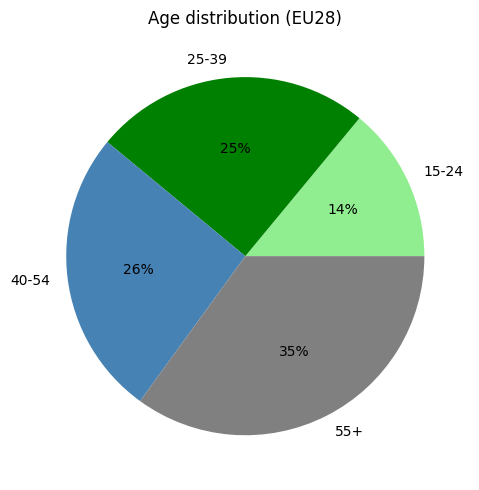

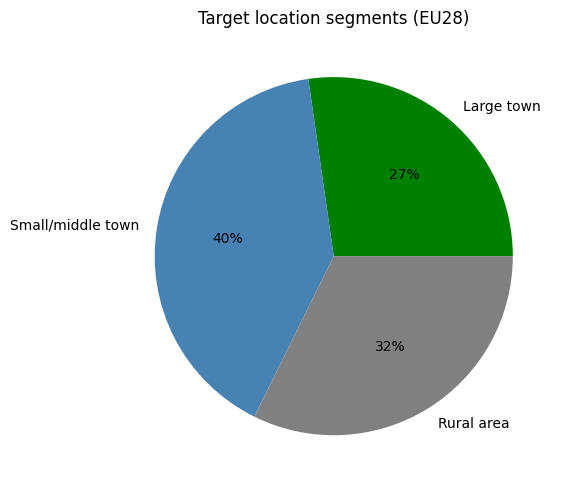

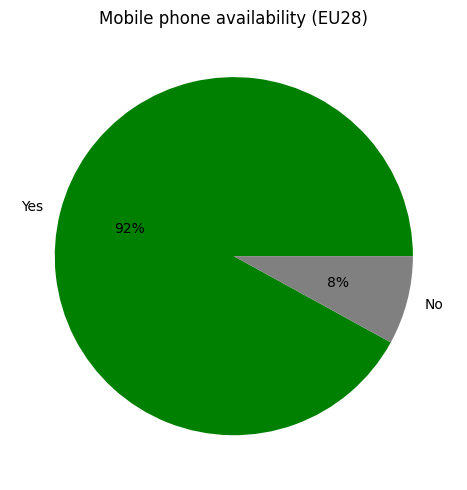

In [45]:
# Age pie
plt.figure(figsize=(6, 5))
plt.pie(
    age_dist.values,
    labels=age_dist.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["lightgreen", "green", "steelblue", "gray"]  # 15-24 & 25-39 in green
)
plt.title("Age distribution (EU28)")
plt.tight_layout()
plt.show()

# AREA pie
plt.figure(figsize=(6, 5))
plt.pie(
    area_groups.values,
    labels=area_groups.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["green", "steelblue", "gray"]
)
plt.title("Target location segments (EU28)")
plt.tight_layout()
plt.show()

# PHONE pie
plt.figure(figsize=(6, 5))
plt.pie(
    phone_groups.values,
    labels=phone_groups.index,
    autopct=lambda p: f"{p:.0f}%",
    colors=["green", "gray"]
)
plt.title("Mobile phone availability (EU28)")
plt.tight_layout()
plt.show()

Demographic data clearly shows how **broad** and **tangible** the audience for a sustainability app can be.

In this interpretation, the color 
<span style="color:green; font-weight:600;">green</span> identifies population segments that are more **easily reachable** through a mobile application,  
<span style="color:steelblue; font-weight:600;">blue</span> represents those that are **moderately reachable**,  
and <span style="color:gray; font-weight:600;">gray</span> indicates those **less likely** to adopt this type of digital tool.

The **15–39 age groups** represent the **primary target**: they account for a significant share of the population and use smartphones on a daily basis.  
On the other hand, older age groups, while potentially sharing some of the issues highlighted in previous analyses, are less inclined to use a dedicated app, reducing the effectiveness of a purely digital intervention.

Geographical distribution also supports this trend: a **significant portion** of the population lives in **urban** or **semi-urban** contexts, where the use of digital applications is more widespread and where services, collection points, and sustainability initiatives are easier to integrate with digital tools.

Moreover, **almost all** respondents have access to a **mobile phone**, making wide app adoption technically feasible.  
This confirms that the issues identified earlier are not only relevant, but also addressable through an accessible digital solution.

This means that the problems identified so far are not only real, but can be concretely tackled with an **accessible tool**.  
Overall, the data suggests that an app focused on recycling and waste reduction can reach a **large, digitalized** audience that is **potentially ready** to change its daily habits.

## Final summary: why this app makes sense (for users, the environment, and economic sustainability)

The results of **Flash Eurobarometer 388** strongly reinforce the idea of a Lifestyle app focused on reducing waste and improving daily habits. The data shows that the problem is real, widespread, and — most importantly — linked to concrete areas for improvement.

**1) The need is perceived (and therefore “marketable” as a problem to solve).**  
A significant share of European citizens recognizes that household waste management is a critical issue. This matters because, in the app market, if users do not feel the problem, they will not download anything.

**2) Recycling exists, but it is incomplete: this is where impact happens.**  
The data on recycled materials highlights a clear gap between what is frequently recycled and what is neglected: for example, **garden waste (57%)** and **kitchen waste (74%)** lag behind **paper and plastic (90%)** and **glass (88%)**.  
This suggests that the app can generate value by targeting areas where behavior is still “halfway there”, offering practical guides, reminders, and simple instructions.

**3) Sustainable habits are not universal yet: there is room to improve.**  
Some actions are widely adopted (e.g., avoiding food waste: **83%**), while others lag behind (e.g., home composting: **44%**).  
This reveals a key point: there is no need to “convince the entire world”, shifting even a portion of users toward better behaviors can create a massive cumulative impact.

**4) The real barrier is often informational (and this is where the app becomes truly useful).**  
The strongest insight is that **94%** agree that information about the environmental impact of products is not clear enough.  
This is exactly where the app stops being theory and becomes practical: label/symbol scanners, disposal instructions, sustainable alternatives, and an instant “translator” between product and action.

**5) Even when interest exists, barriers remain — and the app can break them down.**  
When it comes to purchasing decisions (e.g., second-hand goods), obstacles include **perceived quality (43%)** and **safety/health concerns (41%)**, along with factors such as “never thought about it” (20%).  
Here, the app can step in with micro-education, guides, and trust-building tools (checklists, tips, clear explanations), making sustainable choices easier and less intimidating.

**6) A “reachable” market: demographic data confirms it.**  
The sample shows a strong presence in the 15–39 age range and a high share of smartphone users (**92%**). This makes a digital-first model realistic: the issues identified are not just theoretical, because there is a technically reachable user base for an app.

---

### Product strategy (Lifestyle, but practical)
The app can position itself as a daily anti-waste assistant built on three core pillars:
- **Guide actions** (what do I do with this waste? where do I throw it? how do I sort it?);
- **Make behavior consistent** (personalized reminders, weekly goals, progress tracking);
- **Show impact** (simple visual feedback, not endless lessons).

---

### Business model (free/freemium) aligned with the data
Consistent with the Google Play Store insights, the app should be **free** at its core to maximize adoption and reduce entry friction.  
Monetization can come from an optional **premium tier**, focused on real value (not aggressive paywalls), for example:
- advanced statistics and personalized reports;
- enhanced planning and reminders (family/shared households);
- long-term tracking tools and custom goals;
- “pro” features for motivated users (e.g., consumption profiles, more detailed suggestions).

The takeaway is simple: the data supports the idea that a Lifestyle app focused on recycling and waste reduction can deliver:
- **real utility** (measurable and widespread gaps),
- **plausible adoption** (reachable, highly digital audience),
- **economic potential** (a free/freemium model aligned with market dynamics and user needs).